In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import os
from matplotlib import pyplot as plt
# Set working directory
os.chdir("/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/")

# Verify
print("Current working directory:", os.getcwd())

from torch.utils.data import DataLoader
import numpy as np
from torch_geometric.data import Data

from torch_geometric.data import Dataset, Data
from torch.utils.data import DataLoader

from utils.data.unstructure_dataset import (
    create_ns_dataset,
    )
from utils.data.unstructure_dataset import (
    collate_graph_inr, 
    get_graph_t_idx,
    )
# sys.path.append(str(Path(__file__).parents[1]))
# sys.path.append('/pscratch/sd/g/gzhao27/INR/coral')
from utils.load_inr import create_inr_instance, load_inr_model

from torchdiffeq import odeint
from torch_geometric.data import DataLoader as GDataLoader
import numpy as np
from utils.quadtree import HierarchicalImageGrid
# from train_utility_sampling.SamplerWrapper import InrSamplerWrapper, graph_3d_cluster, graph_2d_cluster, add_cluster_label, sample_random_node_indices_per_cluster
# from mmap_ninja import RaggedMmap
# from hydra import initialize, compose

# NS_inr_save_name = 'NS_keep_for_test_file'
# NS_inr_save_dir = '/pscratch/sd/g/gzhao27/INR/SOMA/results/best_result/'
device = torch.device('cuda')


def load_inr(i, model_dir):
    inr_save_path = os.path.join(model_dir, f"{i}.pt")
    inr_results = torch.load(inr_save_path, weights_only=False)
    cfg = inr_results['cfg']

    # create & load weights
    torch.set_default_dtype(torch.float32)
    inr = create_inr_instance(cfg, input_dim=2, output_dim=1, device=device)
    inr.load_state_dict(inr_results["inr"])
    inr.to(device).eval()
    return inr 

def grad_coor(grad1, grad2):
    return torch.dot(grad1, grad2)/torch.norm(grad1)/torch.norm(grad2)

def loss_function(features_recon, features):
    loss = features_recon
    loss = ((features_recon - features)**2)
    return loss

from train_utility_sampling.SamplerWrapper import create_inr_sampler
from train_utility_sampling.metalearning_sampling import graph_inner_loop, single_image_step

Current working directory: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE


/pscratch/sd/g/gzhao27/conda/torchgeo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# one best full run '/pscratch/sd/g/gzhao27/INR/SOMA/results/best_result/2025-08-14-12-28-58NS1024_single_null_0.0001_lr_5e-4_depth_12_end_128_t100'
# model_dir= '/pscratch/sd/g/gzhao27/INR/SOMA/results/best_result/2025-08-14-12-28-58NS1024_single_null_0.0001_lr_5e-4_depth_12_end_128_t100'
model_dir='/pscratch/sd/g/gzhao27/INR/SOMA/results/inr_sampling/2025-08-15-14-20-15NS1024_single_null_0.001_lr_5e-4_depth_6_end_128_t100'
model_path = os.path.join(model_dir, '0.pt')
save_results = torch.load(model_path, weights_only = False, map_location=device)

print('test single image inr')
cfg = save_results['cfg']
data_path = cfg.data.data_path
data_type = cfg.data.data_type  
seed = cfg.data.seed
trainset = create_ns_dataset(
            datapath = data_path, 
            data_type=data_type, 
            seed=seed,
            single_image=True  # If True, only use one image from the dataset
        )

train_loader = DataLoader(dataset=trainset, collate_fn=collate_graph_inr, batch_size=1, shuffle=False, )
graph = next(iter(train_loader))

inr = create_inr_instance(cfg, input_dim=2, output_dim=1, device=device)
t = cfg.data.single_time_frame 
indices_t = get_graph_t_idx(graph, t)

graph_ori = Data(
    cor=graph.cor[indices_t],
    feat=graph.feat[indices_t],
    time=torch.zeros(len(indices_t)),  # set time to 0 tensor
    space_emb=graph.space_emb[indices_t],
    T=torch.tensor(1),
)

files = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f))]
sorted_files = sorted(files, key=lambda x: int(x.replace('.pt', '')))
print(sorted_files)

test single image inr
['0.pt', '10.pt', '20.pt', '30.pt', '40.pt', '50.pt', '60.pt', '70.pt', '80.pt', '90.pt', '100.pt', '110.pt', '120.pt', '130.pt', '140.pt', '150.pt', '160.pt', '170.pt', '180.pt', '200.pt', '210.pt', '230.pt', '250.pt', '260.pt', '270.pt', '280.pt', '290.pt', '320.pt', '330.pt', '340.pt', '360.pt', '370.pt', '400.pt', '420.pt', '430.pt', '440.pt', '450.pt', '490.pt', '510.pt', '520.pt', '530.pt', '540.pt', '550.pt', '620.pt', '630.pt', '640.pt', '650.pt', '660.pt', '670.pt', '720.pt', '730.pt', '740.pt', '750.pt', '760.pt', '860.pt', '870.pt', '880.pt', '890.pt', '900.pt', '950.pt', '960.pt', '970.pt', '980.pt', '1090.pt', '1100.pt', '1120.pt', '1140.pt', '1150.pt', '1160.pt', '1170.pt', '1180.pt', '1190.pt', '1270.pt', '1280.pt', '1290.pt', '1300.pt', '1370.pt', '1380.pt', '1460.pt', '1470.pt', '1480.pt', '1490.pt', '1580.pt', '1590.pt', '1600.pt', '1610.pt', '1620.pt', '1710.pt', '1720.pt', '1840.pt', '1850.pt', '1940.pt', '1950.pt', '2140.pt', '2150.pt', '3370.

In [16]:
# per pixel loss calculation
t = 100

torch.cuda.empty_cache()
graph = graph_ori.to(device)
H = graph.cor.max().item()+1

features = graph.feat.view(H, H, 1)
coords = graph.space_emb.detach().view(H, H, 2)

rate = 1

center = (341, 341)

features = features[::rate, ::rate]
coords = coords[::rate, ::rate]


inr = load_inr(t, model_dir)
inr.to(device)
reconfeature = inr(coords)

params = list(inr.parameters())
per_pix_losses = loss_function(reconfeature, features)

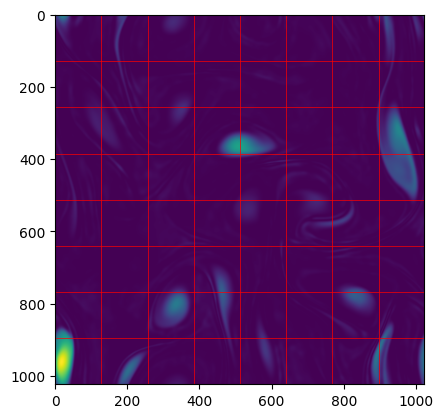

In [5]:
plt.imshow(per_pix_losses[..., 0].detach().cpu())
n_bins = 8
grid_positions = [1024//n_bins*i for i in range(1, n_bins)]
for x in grid_positions:
    plt.axvline(x=x + 0.5, color='r', linewidth=0.5)
    plt.axhline(y=x + 0.5, color='r', linewidth=0.5)

In [6]:

current_date_str = 'test'
run_name = 'test'
outputs = single_image_step(
        inr, 
        graph_ori, 
        iter=0,
        is_train=True,
        return_reconstructions=False,
        use_rel_loss=False,
        sampler=None, 
        cfg = cfg
    )

loss = outputs['loss']
raw_grad = torch.autograd.grad(
                loss, params, retain_graph=False, allow_unused=True
            )
grads_all = [g.view(-1) for g in raw_grad if g is not None]
grad_T = torch.cat(grads_all)

def grad_correlation(grad1, grad2):
    return (torch.matmul(grad1, grad2)/torch.norm(grad1)/torch.norm(grad2)).detach().cpu().item()

def grad_var(grad1, grad2):
    return torch.norm(grad1-grad2).detach().cpu().item()

## Adaptive Sampling sample points show

In [14]:
from train_utility_sampling.taylor_estimation import estimate_frobenius_norm_corrected, grad_estimation, grad_estimation_fully_batched
from utils.quadtree import HierarchicalImageGrid
grid = HierarchicalImageGrid(1024, 1024, initial_grid_size=32)

grid.get_statistics()

center, dimension = grid.get_leaf_centers_tensor()
mname = 'adaptive'

In [47]:
## use gradiant variance ground truth
grid = HierarchicalImageGrid(1024, 1024, initial_grid_size=16)
grad_dict = {}
for g in [16, 32, 64, 128]:
    grad_estimation = np.load(f'/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/test/t_100_grid_{g}_grad_estimation.py.npy')
    gridtemp = HierarchicalImageGrid(1024, 1024, initial_grid_size=g)
    for i, cell in enumerate(gridtemp.get_leaf_cells()):
        cell_key = (cell.x_start, cell.y_start, cell.x_end, cell.y_end)
        grad_dict[cell_key] = grad_estimation[i]
    
def evaluation_function(cell):
    x_start, x_end, y_start, y_end = cell.x_start, cell.x_end, cell.y_start, cell.y_end
    # x_start, x_end, y_start, y_end = cell_cor_range[0].tolist()
    return grad_dict[(x_start, y_start, x_end, y_end)]*(x_end-x_start)*(y_end-y_start)

# evaluation_function = lambda x: cell_grad_variance_estimate_with_jacrev(x, graph, self.model, self.device)

temp = grid.iterative_subdivision(evaluation_function, iterations=5, percentage=10, batch_mode = False)
len(temp)
print(grid.get_statistics())

{'total_cells': 1168, 'leaf_cells': 940, 'max_level': 2, 'levels': [0, 1, 2]}


In [59]:
# evaluation function is cell_grad_variance_estimate_with_jacrev

from train_utility_sampling.taylor_estimation import estimate_frobenius_norm_corrected, grad_estimation, grad_estimation_fully_batched
from utils.quadtree import HierarchicalImageGrid
grid = HierarchicalImageGrid(1024, 1024, initial_grid_size=16)

grid.get_statistics()

center, dimension = grid.get_leaf_centers_tensor()
mname = 'adaptive'

from train_utility_sampling.taylor_estimation import (
    grad_variance_ground_truth,
    cell_grad_variance_estimate_with_norm_corrected,
    cell_grad_variance_estimate_with_jacrev,
)
def evaluation_function(cell):

    cell_cor_range = torch.tensor([[cell.y_start, cell.y_end, cell.x_start, cell.x_end]])
    cell_variance = cell_grad_variance_estimate_with_jacrev(cell_cor_range, graph_ori, inr, device)
    return cell_variance * (cell.y_end - cell.y_start+ 1) * (cell.x_end - cell.x_start+1)

# evaluation_function = lambda x: cell_grad_variance_estimate_with_jacrev(x, graph_ori, inr, device)
grid.iterative_subdivision(evaluation_function, iterations=10, percentage=5, batch_mode = False)
print(grid.get_statistics())

{'total_cells': 1252, 'leaf_cells': 1003, 'max_level': 3, 'levels': [0, 1, 2, 3]}


In [17]:
# evaluation function is loss std* cell area ground truth

from train_utility_sampling.taylor_estimation import estimate_frobenius_norm_corrected, grad_estimation, grad_estimation_fully_batched
from utils.quadtree import HierarchicalImageGrid
grid = HierarchicalImageGrid(1024, 1024, initial_grid_size=16)

grid.get_statistics()

center, dimension = grid.get_leaf_centers_tensor()
mname = 'adaptive'
from train_utility_sampling.SamplerWrapper import INRSingle2dAdaptiveSamplerWrapper

# inr_sampler = create_inr_sampler(cfg, inr, graph_ori, current_date_str, run_name)
sampler =  INRSingle2dAdaptiveSamplerWrapper(inr, 0, image_width=1024, sample_rate=0.001, device=device)

evaluation_function = sampler._create_evaluation_function(graph_ori, mode='loss')

# from train_utility_sampling.taylor_estimation import (
#     grad_variance_ground_truth,
#     cell_grad_variance_estimate_with_norm_corrected,
#     cell_grad_variance_estimate_with_jacrev,
#     grad_variance_ground_truth,
# )
# def evaluation_function(cell):

#     cell_cor_range = torch.tensor([[cell.y_start, cell.y_end, cell.x_start, cell.x_end]])
#     cell_variance = cell_grad_variance_estimate_with_jacrev(cell_cor_range, graph_ori, inr, device)
#     return cell_variance * (cell.y_end - cell.y_start+ 1) * (cell.x_end - cell.x_start+1)

# # evaluation_function = lambda x: cell_grad_variance_estimate_with_jacrev(x, graph_ori, inr, device)
grid.iterative_subdivision(evaluation_function, iterations=10, percentage=5, batch_mode = True)
print(grid.get_statistics())

{'total_cells': 1252, 'leaf_cells': 1003, 'max_level': 3, 'levels': [0, 1, 2, 3]}


<Axes: title={'center': 'Image with Hierarchical Grid Overlay'}>

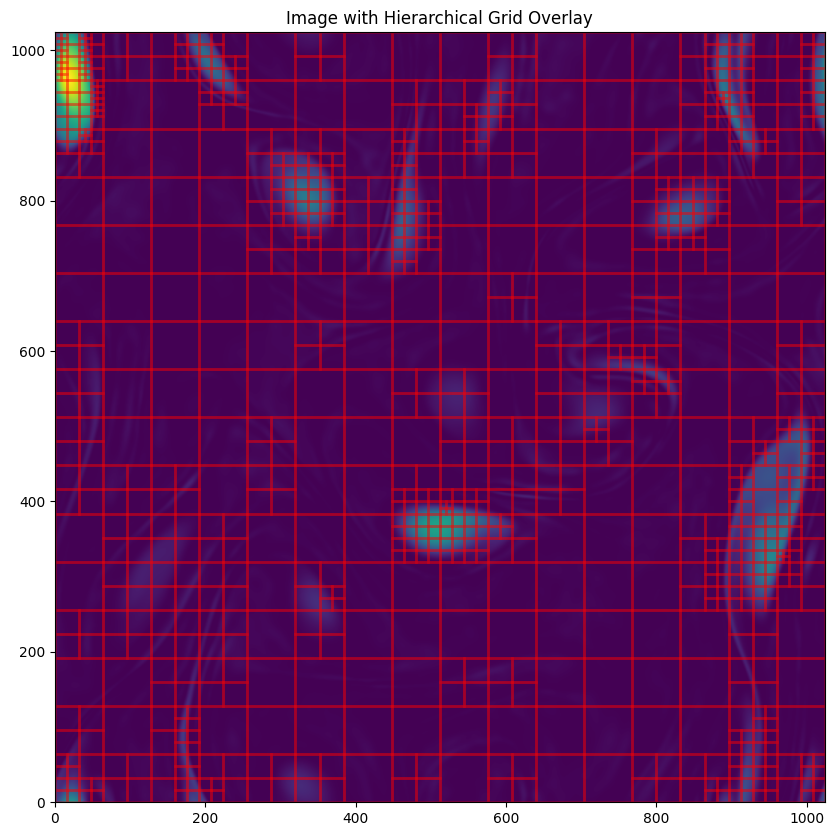

In [31]:
cell_values = grid.evaluate_cells(evaluation_function, batch_mode=True)
new_children = grid.subdivide_top_cells(cell_values, 1)


graph = graph_ori.to(device)
features = graph.feat.view(H, H, 1)
coords = graph.space_emb.detach().view(H, H, 2)

rate = 1

features = features[::rate, ::rate]
coords = coords[::rate, ::rate]

for t in [100]:
    inr = load_inr(t, model_dir)
    reconfeature = inr(coords)

    params = list(inr.parameters())
    
    per_pix_losses = loss_function(reconfeature, features)
image = per_pix_losses[..., 0].detach().cpu()

grid.draw_with_image(image)

In [25]:
bounds, cell_sizes, values = grid.get_leaf_bounds_tensor(device=device)

In [26]:
values[:50]

tensor([1662.7150, 1401.5574,  649.3911,  895.9055, 2048.5125,  331.3402,
         815.2279,  290.3958,  839.2148,  329.0837,  537.7380,  284.6869,
        1405.4314, 1833.4525,  412.2446,  189.3873,  191.2787,  418.1663,
         661.6788,  459.2100,  631.3528,  745.7430,  298.2468,  782.5105,
        1343.7974, 1127.3008, 1004.4222, 1483.6805,   23.9278,  423.9185,
          92.0241,  316.9851,  276.1422,  190.8066,  280.7440, 2440.3740,
         199.5079, 1965.6487, 1290.3395, 1535.9501, 2323.8125,  521.2939,
        1686.3718,  183.1611,  571.8145,  235.9516,  563.5386, 1930.9318,
         432.5157,  992.6077], device='cuda:0')

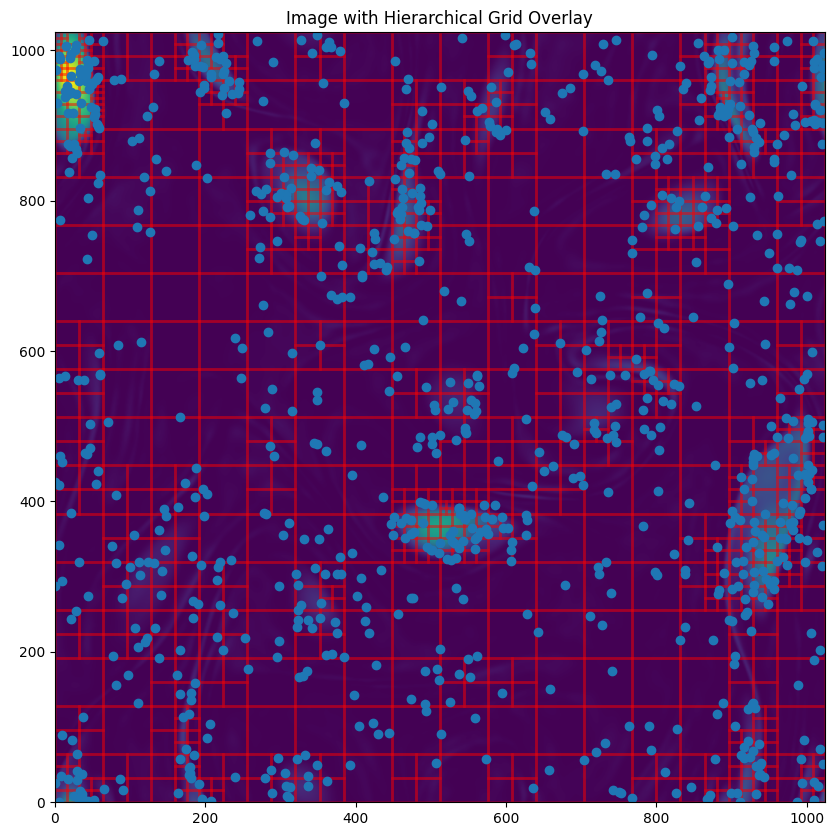

In [17]:
from train_utility_sampling.SamplerWrapper import sample_multiple_from_2d_intervals, sample_variable_from_2d_intervals_vcounts, sample_counts_poisson
bounds, _, values = grid.get_leaf_bounds_tensor()
counts = sample_counts_poisson(values, expected_total=1000)
samples_xy, cell_ids, ptr = sample_variable_from_2d_intervals_vcounts(bounds, counts)
samples = samples_xy
# samples = sample_multiple_from_2d_intervals(bounds, 1)
grid.draw_with_image(image)
plt.scatter(samples[:,  0].cpu(), samples[:, 1].cpu())

In [18]:
loss_per_pixel = per_pix_losses
params = list(inr.parameters())
cell_cor_range = torch.tensor([192, 255, 192, 255])
grad_variance_ground_truth(cell_cor_range, loss_per_pixel, params, graph)

NameError: name 'grad_variance_ground_truth' is not defined

In [19]:
cell_cor_range1 = cell_cor_range.unsqueeze(0)
cell_grad_variance_estimate_with_jacrev(cell_cor_range1, graph, inr, device='cuda:0')

NameError: name 'cell_grad_variance_estimate_with_jacrev' is not defined

##  adaptvie sampler training show

In [78]:
sample_rate = 1e-1
cfg.sampling.type = '2d_grid_adaptive'
inr_sampler = create_inr_sampler(cfg, inr, graph_ori, current_date_str, run_name)
graph, outputs= inr_sampler.sample(
    inner_step = 20, 
    graph = graph_ori.to(device), 
    save_image=True
)

ValueError: too many values to unpack (expected 2)

<Axes: title={'center': 'Image with Hierarchical Grid Overlay'}>

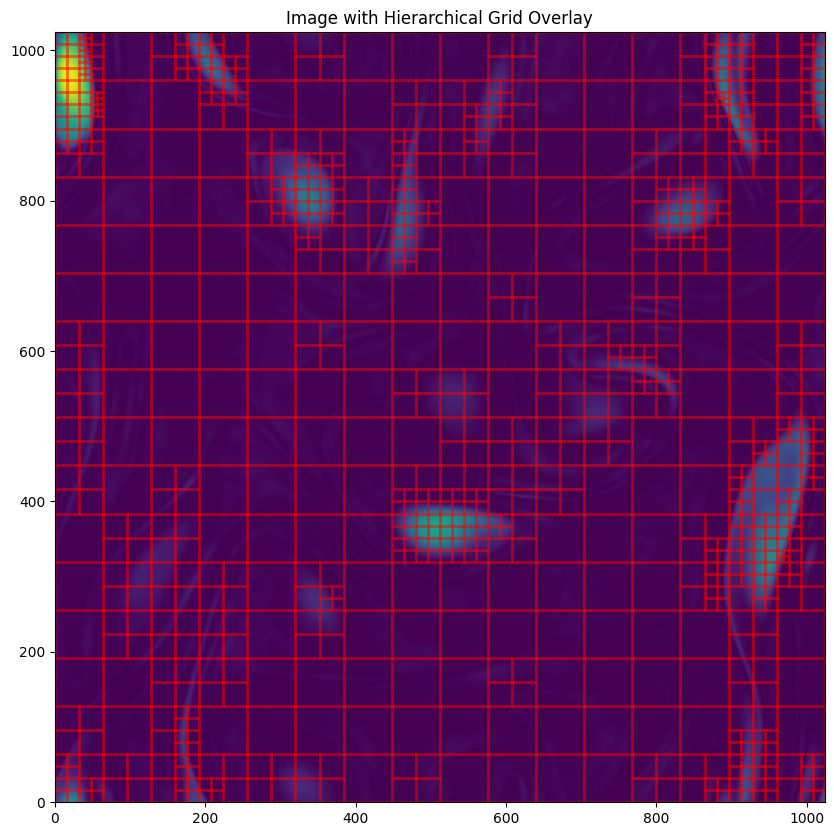

In [68]:
grid = outputs['grid']
grid.draw_with_image(image)

In [20]:
graph

Data(time=[965], cor=[965, 2], feat=[965, 1], space_emb=[965, 2], weight=[965])

In [83]:
cfg.sampling.rate = 1e-3
outputs = single_image_step(
        inr, 
        graph_ori, 
        iter=0,
        is_train=True,
        return_reconstructions=False,
        use_rel_loss=False,
        sampler=inr_sampler, 
        cfg = cfg
    )
print(outputs)

# somehow the loss evaluation is not correct

mse num: tensor(4.7747, device='cuda:0', grad_fn=<SumBackward0>)
{'loss': tensor(6.7909, device='cuda:0', grad_fn=<DivBackward0>), 'reconstructions': None, 'rel_loss': None, 'psnr': None, 'ssim': None}


### other method compare

In [ ]:
sample_rate_list = [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3]
correlation_dict = {}
var_dict = {}
cfg.sampling.n_clusters_2d_start = 10
for stype in ['random', 'NMT', '2d_cluster_grid']:
    cfg.sampling.type = stype
    correlation_dict[stype] = []
    var_dict[stype] = []
    for samplerate in sample_rate_list:
        cfg.sampling.rate = samplerate
        inr_sampler = create_inr_sampler(cfg, inr, graph_ori, current_date_str, run_name)
        outputs = single_image_step(
                inr, 
                graph_ori, 
                iter=0,
                is_train=True,
                return_reconstructions=False,
                use_rel_loss=False,
                sampler=inr_sampler, 
                cfg = cfg
            )
        
        loss = outputs['loss']
        raw_grad = torch.autograd.grad(
                        loss, params, retain_graph=False, allow_unused=True
                    )
        grads_all = [g.view(-1) for g in raw_grad if g is not None]
        grad_ET = torch.cat(grads_all)
        
        correlation_dict[stype].append(grad_correlation(grad_T, grad_ET))
        var_dict[stype].append(grad_var(grad_T, grad_ET)/grad_T.norm().detach().cpu())




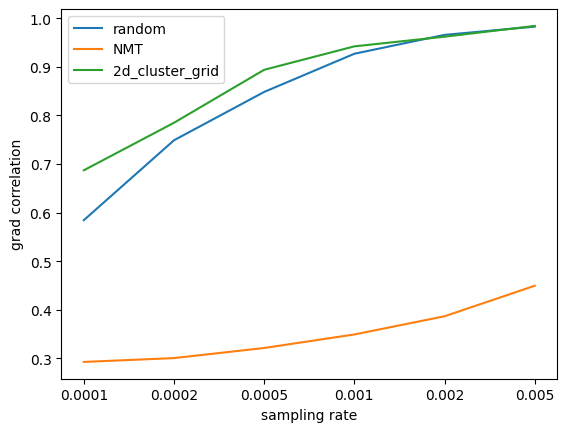

In [9]:
for stype in ['random', 'NMT', '2d_cluster_grid']:
    plt.plot(correlation_dict[stype], label=stype)
plt.xticks([0, 1, 2, 3, 4, 5], sample_rate_list)
plt.xlabel('sampling rate')
plt.ylabel('grad correlation')
plt.legend()

(0.0, 4.0)

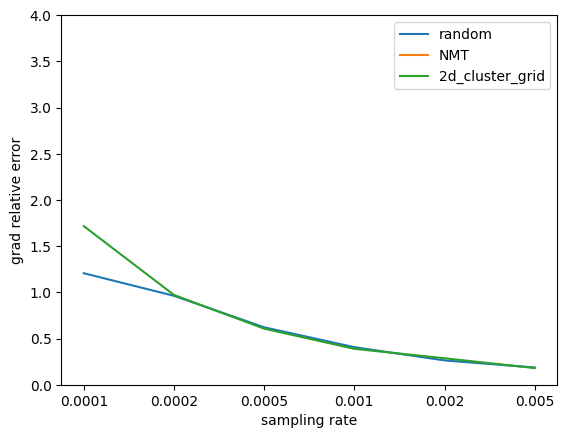

In [10]:
for stype in ['random', "NMT", '2d_cluster_grid']:
    plt.plot(var_dict[stype], label=stype)
plt.xticks([0, 1, 2, 3, 4, 5], sample_rate_list)
plt.xlabel('sampling rate')
plt.ylabel('grad relative error')
plt.legend()
plt.ylim(0, 4)

### grad value function estimate

In [12]:
batch_grad = np.load('all_pixel_grad_t100_rate4.npy')
batch_grad = batch_grad.reshape(256, 256, -1)

In [46]:
def value_function(crop_grad, value_type):
    if value_type == 'correlation':
        crop_grad = torch.tensor(crop_grad)
        crop_grad = crop_grad.reshape(256//seg_number*256//seg_number, -1)
        mean_grad = crop_grad.mean(dim=0)
        correlation = torch.matmul(mean_grad, crop_grad.T).abs()/torch.norm(mean_grad)/torch.norm(crop_grad, dim=1)
        return correlation.std()
    if value_type == 'variance':
        crop_grad = crop_grad.reshape(256//seg_number*256//seg_number, -1)
        mean_grad = crop_grad.mean(axis=(0))
        grad_var = crop_grad.var(axis = (0)).sum()
        return np.sqrt(grad_var)
    if value_type == 'projection':
        crop_grad = torch.from_numpy(crop_grad)
        crop_grad = crop_grad.reshape(256//seg_number*256//seg_number, -1)
        proj_grad = torch.matmul(total_grad, crop_grad.T).abs()/torch.norm(total_grad)
        return proj_grad.std()
        

In [78]:
from train_utility_sampling.SamplerWrapper import create_inr_sampler
from train_utility_sampling.metalearning_sampling import graph_inner_loop, single_image_step
current_date_str = 'test'
run_name = 'test'
outputs = single_image_step(
        inr, 
        graph_ori, 
        iter=0,
        is_train=True,
        return_reconstructions=False,
        use_rel_loss=False,
        sampler=None, 
        cfg = cfg
    )

loss = outputs['loss']
raw_grad = torch.autograd.grad(
                loss, params, retain_graph=False, allow_unused=True
            )
grads_all = [g.view(-1) for g in raw_grad if g is not None]
grad_T = torch.cat(grads_all)

def grad_correlation(grad1, grad2):
    return (torch.matmul(grad1, grad2)/torch.norm(grad1)/torch.norm(grad2)).detach().cpu().item()

def grad_var(grad1, grad2):
    return torch.norm(grad1-grad2).detach().cpu().item()
sample_rate_list = [1e-3, 2e-3, 5e-3]
correlation_dict = {}
var_dict = {}
cfg.sampling.n_clusters_2d_start = 16
for stype in ['random', 'NMT', '2d_cluster_grid']:
    cfg.sampling.type = stype
    correlation_dict[stype] = []
    var_dict[stype] = []
    for samplerate in sample_rate_list:
        cfg.sampling.rate = samplerate
        inr_sampler = create_inr_sampler(cfg, inr, graph_ori, current_date_str, run_name)
        outputs = single_image_step(
                inr, 
                graph_ori, 
                iter=0,
                is_train=True,
                return_reconstructions=False,
                use_rel_loss=False,
                sampler=inr_sampler, 
                cfg = cfg
            )
        
        loss = outputs['loss']
        raw_grad = torch.autograd.grad(
                        loss, params, retain_graph=False, allow_unused=True
                    )
        grads_all = [g.view(-1) for g in raw_grad if g is not None]
        grad_ET = torch.cat(grads_all)
        
        correlation_dict[stype].append(grad_correlation(grad_T, grad_ET))
        var_dict[stype].append(grad_var(grad_T, grad_ET)/grad_T.norm().detach().cpu())

(0.9, 1.0)

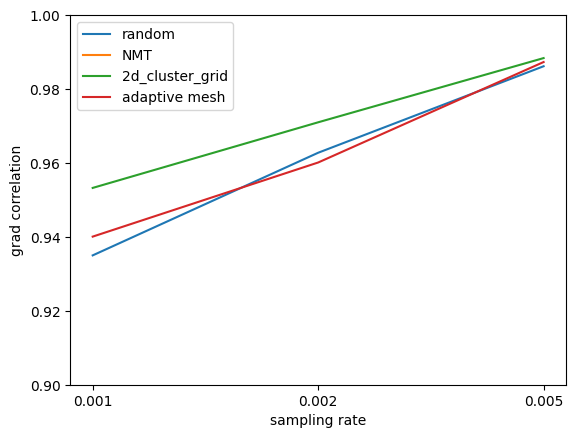

In [184]:
for stype in var_dict.keys():
    plt.plot(correlation_dict[stype], label=stype)
plt.xticks([0, 1, 2], sample_rate_list)
plt.xlabel('sampling rate')
plt.ylabel('grad correlation')
plt.legend()
plt.ylim(0.9, 1.0)

(0.0, 1.0)

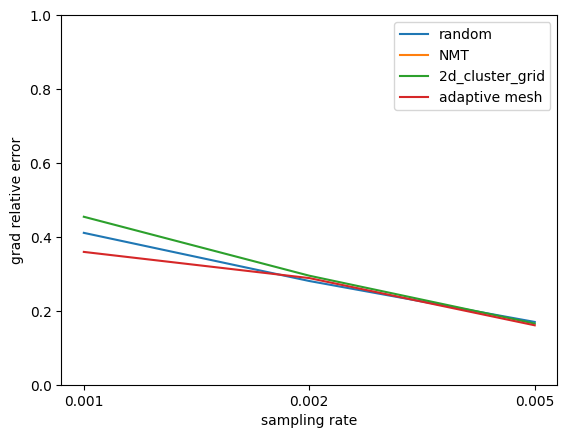

In [185]:
for stype in correlation_dict.keys():
    plt.plot(var_dict[stype], label=stype)
plt.xticks([0, 1, 2], sample_rate_list)
plt.xlabel('sampling rate')
plt.ylabel('grad relative error')
plt.legend()
plt.ylim(0, 1)

### draw image qualititive illustration

In [124]:
def sample_multiple_from_intervals(bounds, n_samples, device='cuda'):
    """
    Sample multiple integers from each interval.
    
    Args:
        bounds: tensor of shape (n_intervals, 2)
        n_samples: number of samples per interval
        device: device to run on
    
    Returns:
        tensor of shape (n_intervals, n_samples)
    """
    bounds = bounds.to(device)
    n_intervals = len(bounds)
    
    # Expand bounds for vectorized sampling
    low = bounds[:, 0].unsqueeze(1).expand(n_intervals, n_samples)
    high = bounds[:, 1].unsqueeze(1).expand(n_intervals, n_samples)
    
    rand_vals = torch.rand(n_intervals, n_samples, device=device)
    samples = low + torch.floor(rand_vals * (high - low + 1)).long()
    
    return samples

def generate_equal_bins(low, high, n_bins, device='cuda'):
    """
    Generate bin bounds with similar widths (max difference = 1).
    
    Args:
        low: lower bound of the range
        high: upper bound of the range (inclusive)
        n_bins: number of bins to create
        device: device to run on
    
    Returns:
        tensor of shape (n_bins, 2) containing [start, end] for each bin
    """
    device = torch.device(device)
    
    # Total range (inclusive)
    total_range = high - low + 1
    
    # Base width for each bin
    base_width = total_range // n_bins
    
    # Number of bins that need one extra element
    remainder = total_range % n_bins
    
    # Create bin bounds
    bounds = torch.zeros(n_bins, 2, dtype=torch.long, device=device)
    
    current_pos = low
    for i in range(n_bins):
        # First 'remainder' bins get base_width + 1, others get base_width
        width = base_width + (1 if i < remainder else 0)
        
        bounds[i, 0] = current_pos  # start of bin
        bounds[i, 1] = current_pos + width - 1  # end of bin (inclusive)
        
        current_pos += width
    
    return bounds

In [130]:
bounds

tensor([[   0,  511],
        [ 512, 1023]])

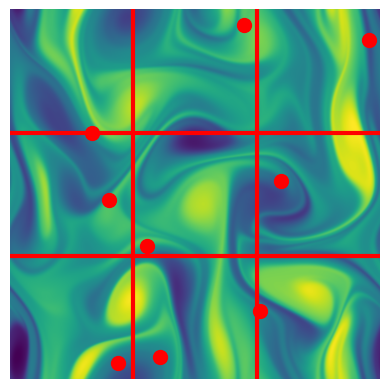

In [174]:

plt.imshow(graph.feat.cpu().numpy().reshape(1024, 1024))
plt.axis('off')
n_bins = 3


bounds = generate_equal_bins(0, 1024-1, n_bins, device='cpu')  # Example usage on CPU
cor = sample_multiple_from_intervals(bounds, n_bins*2, device='cpu')  # Example usage on CPU
cor1 = cor[:, :n_bins]
cor2 = cor[:, n_bins:].T

grid_positions = [1024//n_bins*i for i in range(1, n_bins)]
for x in grid_positions:
    plt.axvline(x=x + 0.5, color='r', linewidth=3)
    plt.axhline(y=x + 0.5, color='r', linewidth=3)
    
    
plt.scatter(cor1.flatten(), cor2.flatten(), color='red', s= 100)
    

# count = 0
# for i in range(len(grid_positions) - 1):
#     for j in range(len(grid_positions) - 1):
#         # centre of the cell in pixel coordinates
#         x_center = (grid_positions[j] + grid_positions[j+1]) / 2 - 0.5
#         y_center = (grid_positions[i] + grid_positions[i+1]) / 2 - 0.5
#         plt.text(x_center, y_center, str(count),
#                  ha='center', va='center',
#                  color='blue', fontsize=12)
# plt.figure(figsize=(10, 5))
# plt.imshow(features_recon.cpu().detach().numpy(), cmap='jet')

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

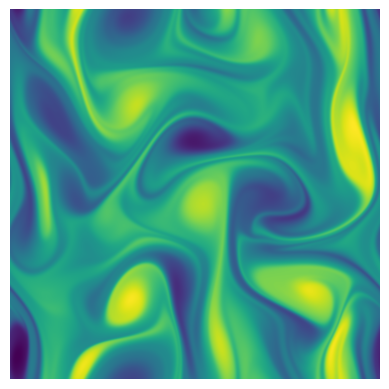

In [176]:
plt.imshow(graph.feat.cpu().numpy().reshape(1024, 1024))
plt.axis('off')

In [141]:
cor1.flatten()

tensor([497, 341, 689, 513])

In [139]:
cor1

tensor([[497, 341],
        [689, 513]])

In [140]:
cor2

tensor([[271, 819],
        [ 15, 697]])

In [138]:
cor

tensor([[497, 341, 271,  15],
        [689, 513, 819, 697]])

In [131]:
num_count = torch.zeros(1024)
for _ in range(100000):
    cor = sample_multiple_from_intervals(bounds, n_bins*2, device='cpu')
    tempcount = torch.bincount(cor.flatten())
    num_count[:len(tempcount)] += tempcount



In [134]:
num_count[500:600]

tensor([778., 795., 743., 808., 738., 812., 789., 800., 767., 738., 823., 768.,
        772., 787., 777., 725., 736., 765., 770., 745., 729., 759., 807., 770.,
        788., 741., 807., 825., 785., 781., 823., 725., 720., 791., 812., 753.,
        774., 750., 833., 803., 786., 796., 813., 755., 813., 806., 790., 782.,
        775., 799., 780., 778., 734., 736., 798., 773., 760., 795., 766., 784.,
        792., 767., 764., 727., 743., 790., 782., 808., 753., 803., 800., 826.,
        782., 735., 800., 773., 786., 768., 751., 761., 824., 828., 763., 805.,
        764., 786., 766., 825., 789., 761., 774., 772., 845., 739., 777., 786.,
        799., 813., 756., 792.])

(array([2., 3., 2., 1., 2., 2., 1., 2., 3., 2.]),
 array([100. , 178.7, 257.4, 336.1, 414.8, 493.5, 572.2, 650.9, 729.6,
        808.3, 887. ]),
 <BarContainer object of 10 artists>)

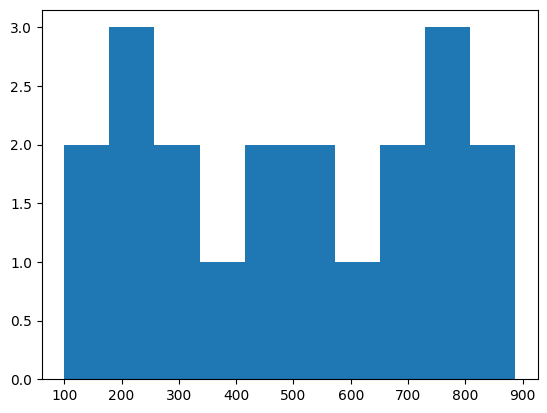

In [101]:
plt.hist(cor.flatten())


In [33]:
cor1

tensor([[116,  29,  16,  48],
        [483, 349, 389, 445],
        [538, 667, 755, 762],
        [819, 940, 933, 907]])

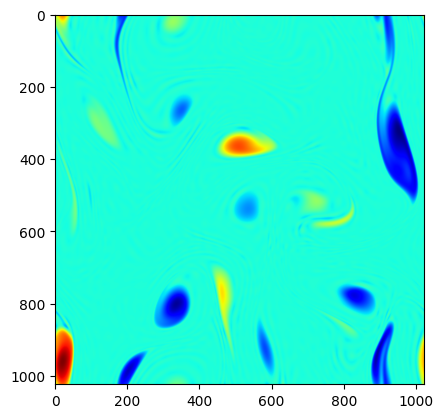

In [51]:
plt.imshow(features_recon.cpu().detach().numpy() - graph.feat.cpu().numpy().reshape(1024, 1024), cmap='jet')

In [14]:
from Run_Test import *

ModuleNotFoundError: No module named 'coralsoma'

In [ ]:
variables = test_inr_sample('3d_cluster')

In [42]:
variables = test_single_image_inr('2d_cluster')

test single image inr
loss: 0.610024631023407
rel loss: 1.0111850500106812


In [6]:
graph = variables['graph']
graph.cpu()

Data(time=[4096], cor=[4096, 2], feat=[4096, 1], space_emb=[4096, 2], T=1, cluster_set=[1], segments=[1])

In [56]:
graph_2d_cluster_single_image(graph, 100, compactness=0.1, cluster_type='slic')

In [57]:
graph.segments[0].max()

np.int64(118)

In [59]:
inr = variables['inr']

In [61]:
sum(p.numel() for p in inr.parameters() if p.requires_grad)

1185

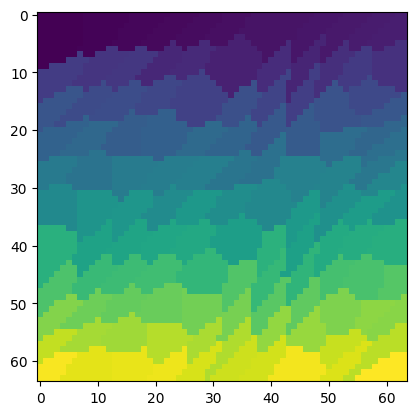

In [58]:
from matplotlib import pyplot as plt
plt.imshow(graph.segments[0])

In [12]:
import wandb
import pandas as pd

# Create API object
api = wandb.Api()

# Replace with your username/entity and project name
entity = "bnl-lemon"
project = "neurips-workshop-inr-sampling"

# Get all runs in the project
runs = api.runs(f"{entity}/{project}")

# Collect run data
time_list, config_list, name_list = [], [], []

for run in runs:
    if "5e-4" in run.name:
        continue

    if "NMT" in run.name:
        
    # # Summary metrics (final values)
    # summary_list.append(run.summary._json_dict)
    # # Config parameters
    # config_list.append({k: v for k, v in run.config.items() if not k.startswith('_')})
    # # Run name
    # name_list.append(run.name)

# Combine into a DataFrame
df = pd.DataFrame({
    "name": name_list,
    "config": config_list,
    "summary": summary_list
})

print(df.head())


                                                name  \
0  NS1024_single_NMT_0.001_lr_5e-4_depth_6_end_12...   
1  NS1024_single_random_0.001_lr_5e-4_depth_6_end...   
2  NS1024_single_2d_cluster_grid_0.001_lr_5e-4_de...   
3  NS1024_single_EVOS_0.001_lr_5e-4_depth_6_end_1...   
4  NS1024_single_NMT_0.001_lr_5e-4_depth_6_end_12...   

                                              config  \
0  {'inr': {'w0': 30, 'depth': 6, 'loss_type': 'm...   
1  {'inr': {'w0': 30, 'depth': 6, 'loss_type': 'm...   
2  {'inr': {'w0': 30, 'depth': 6, 'loss_type': 'm...   
3  {'inr': {'w0': 30, 'depth': 6, 'loss_type': 'm...   
4  {'inr': {'w0': 30, 'depth': 6, 'loss_type': 'm...   

                                             summary  
0  {'Time': 170.77354645729065, '_runtime': 275.9...  
1  {'Time': 15.143675327301024, '_runtime': 101.6...  
2  {'Time': 22.89962124824524, '_runtime': 115.50...  
3  {'Time': 29.03055763244629, '_runtime': 101.60...  
4  {'Time': 170.41129446029663, '_runtime': 273.7..

In [21]:
run.history()

,Time,psnr,test_loss,train_rel_loss,ssim,_runtime,_timestamp,train_loss,_step,test_rel_loss
0,0.459452,17.549164,28.926556,0.974325,0.001904,4.730480,1.755282e+09,216.653687,10,0.976502
1,0.510752,17.758789,27.563484,0.965602,0.007296,4.933698,1.755282e+09,212.107574,20,0.953217
2,0.564223,17.962273,26.301836,0.957289,0.015429,5.135529,1.755282e+09,208.756653,30,0.931146
3,0.616634,18.153378,25.169538,0.948619,0.027493,5.337400,1.755282e+09,205.653229,40,0.910883
4,0.669557,18.348587,24.063263,0.940358,0.042426,5.539310,1.755282e+09,201.997498,50,0.890640
...,...,...,...,...,...,...,...,...,...,...
495,29.142110,33.573982,0.722462,0.149120,0.852598,101.856838,1.755283e+09,0.775498,4960,0.154324
496,29.184635,34.812206,0.543241,0.109165,0.873633,102.034710,1.755283e+09,0.405353,4970,0.133820
497,29.227265,35.717693,0.441005,0.098420,0.890755,102.212590,1.755283e+09,0.324557,4980,0.120572
498,29.270730,36.517002,0.366871,0.076177,0.902535,102.385773,1.755283e+09,0.211765,4990,0.109972
